# Population Structure Analysis Pipeline
### 1000 Genomes Project – Chr1 Biallelic SNVs

**Workflow:** VCF → PLINK (QC) → LD Pruning → PCA → ADMIXTURE → Plots

---

## 0. Environment Setup

In [7]:
import subprocess
import os
import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

def run(cmd):
    subprocess.run(cmd, shell=True, check=True)

print("Done")

Done


---
## 1. Configuration
All pipeline parameters in one place — edit here to customise the run.

In [84]:
import os
from pathlib import Path

# ── Add conda environment to PATH so tools like plink2/admixture are found ────
os.environ['PATH'] = '/opt/anaconda3/bin:' + os.environ['PATH']

# ── Directories ───────────────────────────────────────────────────────────────
FOLDER = Path("1000G_analysis")
RAWDIR    = FOLDER / "00_raw"
PLINKDIR  = FOLDER / "01_plink"
PRUNED    = FOLDER / "02_pruned"
PCADIR    = FOLDER / "03_pca"
ADMIXDIR  = FOLDER / "04_admixture"
PLOTDIR   = FOLDER / "05_plots"

for d in [RAWDIR, PLINKDIR, PRUNED, PCADIR, ADMIXDIR, PLOTDIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── QC parameters ─────────────────────────────────────────────────────────────
THREADS    = 8       # parallel threads
MAF        = 0.05    # minor allele frequency minimum
GENO       = 0.05    # max per-SNP missing rate
MIND       = 0.10    # max per-sample missing rate
HWE        = 1e-6    # Hardy-Weinberg p-value threshold

# ── LD pruning ────────────────────────────────────────────────────────────────
LD_WINDOW  = 50      # window size (kb)
LD_STEP    = 5       # step size
LD_R2      = 0.05     # r² threshold

# ── ADMIXTURE ─────────────────────────────────────────────────────────────────
K_MIN      = 2
K_MAX      = 6

# ── Data URLs ─────────────────────────────────────────────────────────────────
BASE_URL   = "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20181203_biallelic_SNV"
VCF_NAME   = "ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz"
PANEL_URL  = "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20200731.ALL.panel"

VCF_PATH   = VCF_NAME
PANEL_PATH = RAWDIR / "sample_panel.tsv"

# Download panel if not present
run(f"curl -L -o {PANEL_PATH} 'https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel'")

print("Done. Working directory:", FOLDER.resolve())

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0

Done. Working directory: /Users/apc/Documents/Education/UZH/sem6/BIO392/Exercises/Day10_Exercise/1000G_analysis


100  55156 100  55156   0      0 250.2k      0                              0


In [60]:


with open(PANEL_PATH) as f:
    print(f.read(500))

sample	pop	super_pop	gender		
HG00096	GBR	EUR	male
HG00097	GBR	EUR	female
HG00099	GBR	EUR	female
HG00100	GBR	EUR	female
HG00101	GBR	EUR	male
HG00102	GBR	EUR	female
HG00103	GBR	EUR	male
HG00105	GBR	EUR	male
HG00106	GBR	EUR	female
HG00107	GBR	EUR	male
HG00108	GBR	EUR	male
HG00109	GBR	EUR	male
HG00110	GBR	EUR	female
HG00111	GBR	EUR	female
HG00112	GBR	EUR	male
HG00113	GBR	EUR	male
HG00114	GBR	EUR	male
HG00115	GBR	EUR	male
HG00116	GBR	EUR	male
HG00117	GBR	EUR	male
HG00118	GBR	EUR	female
HG00119	GBR	E


---
## 3. VCF → PLINK Binary Format

In [27]:
%cd /Users/apc/Documents/Education/UZH/sem6/BIO392/Exercises/Day10_Exercise 
!pwd

/Users/apc/Documents/Education/UZH/sem6/BIO392/Exercises/Day10_Exercise
/Users/apc/Documents/Education/UZH/sem6/BIO392/Exercises/Day10_Exercise


In [28]:
run(f"""
plink \\
    --vcf {VCF_PATH} \\
    --make-bed \\
    --out {PLINKDIR}/chr1_raw \\
    --threads {THREADS} \\
    --double-id \\
    --vcf-half-call missing
""")

n_snps    = int(subprocess.run(f"wc -l < {PLINKDIR}/chr1_raw.bim", shell=True, capture_output=True, text=True).stdout.strip())
n_samples = int(subprocess.run(f"wc -l < {PLINKDIR}/chr1_raw.fam", shell=True, capture_output=True, text=True).stdout.strip())
print(f"\nDone: {n_snps:,} SNPs | {n_samples:,} samples")

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to 1000G_analysis/01_plink/chr1_raw.log.
Options in effect:
  --double-id
  --make-bed
  --out 1000G_analysis/01_plink/chr1_raw
  --threads 8
  --vcf ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz
  --vcf-half-call missing

8192 MB RAM detected; reserving 4096 MB for main workspace.
--vcf: 1000G_analysis/01_plink/chr1_raw-temporary.bed +
1000G_analysis/01_plink/chr1_raw-temporary.bim +
1000G_analysis/01_plink/chr1_raw-temporary.fam written.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to 1000G_analysis/01_plink/chr1_raw.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627

---
## 4. Quality Control

| Filter | Threshold | Rationale |
|--------|-----------|----------|
| MAF | > 0.05 | Remove rare variants |
| GENO | < 0.05 | Remove SNPs missing in > 5% samples |
| MIND | < 0.10 | Remove samples missing > 10% SNPs |
| HWE | p > 1×10⁻⁶ | Remove SNPs deviating from HWE |

In [29]:
run(f"""
plink \\
    --bfile {PLINKDIR}/chr1_raw \\
    --maf {MAF} \\
    --geno {GENO} \\
    --mind {MIND} \\
    --hwe {HWE} \\
    --snps-only \\
    --make-bed \\
    --out {PLINKDIR}/chr1_qc \\
    --threads {THREADS}
""")

n_snps_qc    = int(subprocess.run(f"wc -l < {PLINKDIR}/chr1_qc.bim", shell=True, capture_output=True, text=True).stdout.strip())
n_samples_qc = int(subprocess.run(f"wc -l < {PLINKDIR}/chr1_qc.fam", shell=True, capture_output=True, text=True).stdout.strip())
print(f"\nAfter QC: {n_snps_qc:,} SNPs | {n_samples_qc:,} samples")
print(f"   Removed: {n_snps - n_snps_qc:,} SNPs | {n_samples - n_samples_qc:,} samples")

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to 1000G_analysis/01_plink/chr1_qc.log.
Options in effect:
  --bfile 1000G_analysis/01_plink/chr1_raw
  --geno 0.05
  --hwe 1e-06
  --maf 0.05
  --make-bed
  --mind 0.1
  --out 1000G_analysis/01_plink/chr1_qc
  --snps-only
  --threads 8

8192 MB RAM detected; reserving 4096 MB for main workspace.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to 1000G_analysis/01_plink/chr1_qc.nosex .
0 people removed due to missing genotype data (--mind).
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081

---
## 5. LD Pruning

PCA and ADMIXTURE assume independent SNPs. Correlated SNPs (high LD) bias results toward genomic regions with many variants. We prune to r² < 0.2 in 50 kb windows.

In [76]:
# Step 1: identify SNPs to keep / remove
run(f"""
plink \
    --bfile {PLINKDIR}/chr1_qc \
    --indep-pairwise {LD_WINDOW} {LD_STEP} {LD_R2} \
    --out {PRUNED}/chr1_pruning \
    --threads {THREADS}
""")

# Step 2: extract pruned set
run(f"""
plink \
    --bfile {PLINKDIR}/chr1_qc \
    --extract {PRUNED}/chr1_pruning.prune.in \
    --make-bed \
    --out {PRUNED}/chr1_pruned \
    --threads {THREADS}
""")

# Step 3: thin down to ~10000 SNPs
run(f"""
plink \
    --bfile {PRUNED}/chr1_pruned \
    --thin-count 10000 \
    --make-bed \
    --out {PRUNED}/chr1_pruned_10k
""")

# Check the RIGHT file (10k version)
n_pruned = int(subprocess.run(f"wc -l < {PRUNED}/chr1_pruned_10k.bim", shell=True, capture_output=True, text=True).stdout.strip())
print(f"SNPs after pruning + thinning: {n_pruned:,}")

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to 1000G_analysis/02_pruned/chr1_pruning.log.
Options in effect:
  --bfile 1000G_analysis/01_plink/chr1_qc
  --indep-pairwise 50 5 0.05
  --out 1000G_analysis/02_pruned/chr1_pruning
  --threads 8

8192 MB RAM detected; reserving 4096 MB for main workspace.
333378 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to 1000G_analysis/02_pruned/chr1_pruning.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
333378 variant

3031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
333378 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed to 1000G_analysis/02_pruned/chr1_pruned.bed +
1000G_analysis/02_pruned/chr1_pruned.bim +
1000G_analysis/02_pruned/chr1_pruned.fam ... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990919293949596979899done.
PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to 1000G_analysis/02_pruned/chr1_pruned_10k.log.
Options in effect:
  --bfile 1000G_analysis/02_pruned/chr1_pruned
  --make-bed
  --out 1000G_analysis/02_pruned/chr1_pruned_10k
  --thin-count 10000

8192 MB RAM detected; reserving 4096 MB

---
## 6. PCA

In [79]:
run(f"""
plink \\
    --bfile {PRUNED}/chr1_pruned_10k \\
    --pca 20 \\
    --out {PCADIR}/chr1_pca \\
    --threads {THREADS}
""")

print(f"PCA complete → {PCADIR}/chr1_pca.eigenvec / .eigenval")

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to 1000G_analysis/03_pca/chr1_pca.log.
Options in effect:
  --bfile 1000G_analysis/02_pruned/chr1_pruned_10k
  --out 1000G_analysis/03_pca/chr1_pca
  --pca 20
  --threads 8

8192 MB RAM detected; reserving 4096 MB for main workspace.
10000 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to 1000G_analysis/03_pca/chr1_pca.nosex .
Using up to 8 threads (change this with --threads).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
10000 variants and 2548 people pass filters and Q

---
## 7. ADMIXTURE (K = 2 to 6)

In [85]:
import shutil

# Copy pruned files into admixture dir (admixture writes output next to input)
for ext in [".bed", ".bim", ".fam"]:
    shutil.copy(str(PRUNED / f"chr1_pruned_10k{ext}"), str(ADMIXDIR / f"chr1_pruned_10k{ext}"))

for k in range(K_MIN, K_MAX + 1):
    print(f"\n--- Running ADMIXTURE K={k} ---")
    run(f"""
    cd {ADMIXDIR} && admixture \
        -j{THREADS} \
        chr1_pruned_10k.bed {k} \
        | tee admixture_10k_K{k}.log
    """)

print("\nADMIXTURE complete.")


--- Running ADMIXTURE K=2 ---
****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 8 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x10000
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 2.341	Loglikelihood: -2.47517e+07	(delta): 1.89e+07
2 (EM) 	Ela

---
## 8. Load Results for Plotting

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SUPER_COLORS = {
    "AFR": "#E41A1C",
    "AMR": "#FF7F00",
    "EAS": "#4DAF4A",
    "EUR": "#377EB8",
    "SAS": "#984EA3",
}

# ── Load panel ────────────────────────────────────────────────────────────────
panel = pd.read_csv(PANEL_PATH, sep=r"\s+")
panel.columns = [c.lower().replace(" ", "_") for c in panel.columns]
# Normalise column names across panel versions
col_map = {"sample": "IID", "super_population": "super_pop", "population": "pop"}
panel = panel.rename(columns={k: v for k, v in col_map.items() if k in panel.columns})
if "IID" not in panel.columns:
    panel = panel.rename(columns={panel.columns[0]: "IID"})

# ── Load PCA ──────────────────────────────────────────────────────────────────
evec = pd.read_csv(f"{PCADIR}/chr1_pca.eigenvec", sep=r"\s+")
evec.columns = [c.lstrip("#") for c in evec.columns]
if "IID" not in evec.columns:
    evec.columns = ["FID", "IID"] + [f"PC{i+1}" for i in range(evec.shape[1] - 2)]

eval_ = np.loadtxt(f"{PCADIR}/chr1_pca.eigenval")

# ── Load ADMIXTURE ────────────────────────────────────────────────────────────
fam = pd.read_csv(f"{PRUNED}/chr1_pruned_10k.fam", sep=r"\s+", header=None,
                  names=["FID","IID","PID","MID","SEX","PHENO"])
admix = {}
for k in range(K_MIN, K_MAX + 1):
    qf = ADMIXDIR / f"chr1_pruned_10k.{k}.Q"
    if qf.exists():
        q = pd.read_csv(qf, sep=r"\s+", header=None,
                        names=[f"K{i+1}" for i in range(k)])
        q["IID"] = fam["IID"].values
        admix[k] = q

print(f"✅ Loaded: {len(evec)} samples | {len(admix)} ADMIXTURE runs")
evec.head(3)

✅ Loaded: 2547 samples | 5 ADMIXTURE runs


,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,HG00097,HG00097,-0.009813,0.026976,0.009735,-0.016549,0.002736,-0.000558,0.033805,-0.005376,...,-0.010251,0.015696,0.036341,0.015126,0.007465,0.027764,-0.011031,-0.029049,-0.037364,-0.013788
1,HG00099,HG00099,-0.011577,0.029394,0.014977,-0.017693,0.005056,-0.014239,-0.013495,-0.034868,...,0.008882,0.010040,-0.023716,-0.017457,0.020146,-0.016320,0.021260,0.017632,-0.008337,0.035200
2,HG00100,HG00100,-0.006832,0.029928,0.013909,-0.010245,0.011473,-0.001518,-0.032382,0.032656,...,-0.032814,0.003370,-0.018711,0.024429,-0.015129,-0.014034,0.001425,0.001531,-0.019316,0.026908


---
## 9. PCA – Variance Explained

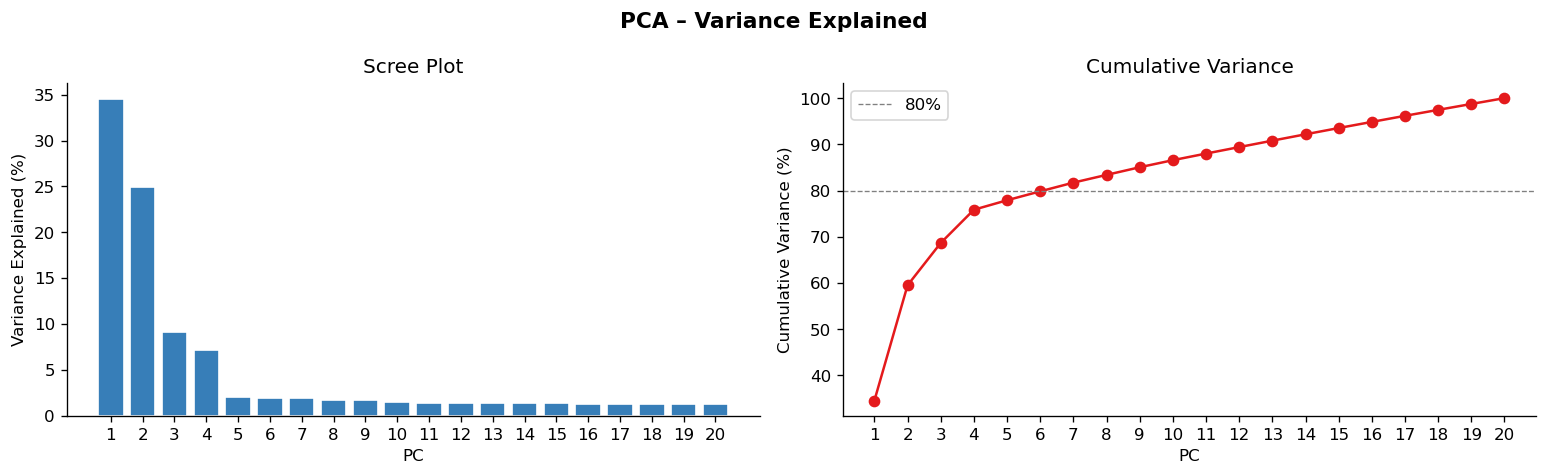

In [89]:
pct = eval_ / eval_.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pct)+1), pct, color="#377EB8", edgecolor="white")
axes[0].set(xlabel="PC", ylabel="Variance Explained (%)", title="Scree Plot")
axes[0].set_xticks(range(1, len(pct)+1))

axes[1].plot(range(1, len(pct)+1), np.cumsum(pct), "o-", color="#E41A1C")
axes[1].axhline(80, ls="--", color="grey", lw=0.8, label="80%")
axes[1].set(xlabel="PC", ylabel="Cumulative Variance (%)", title="Cumulative Variance")
axes[1].set_xticks(range(1, len(pct)+1))
axes[1].legend()

plt.suptitle("PCA – Variance Explained", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTDIR / "pca_variance.png", bbox_inches="tight")
plt.show()

---
## 10. PCA – Scatter Plots (PC1/2/3)

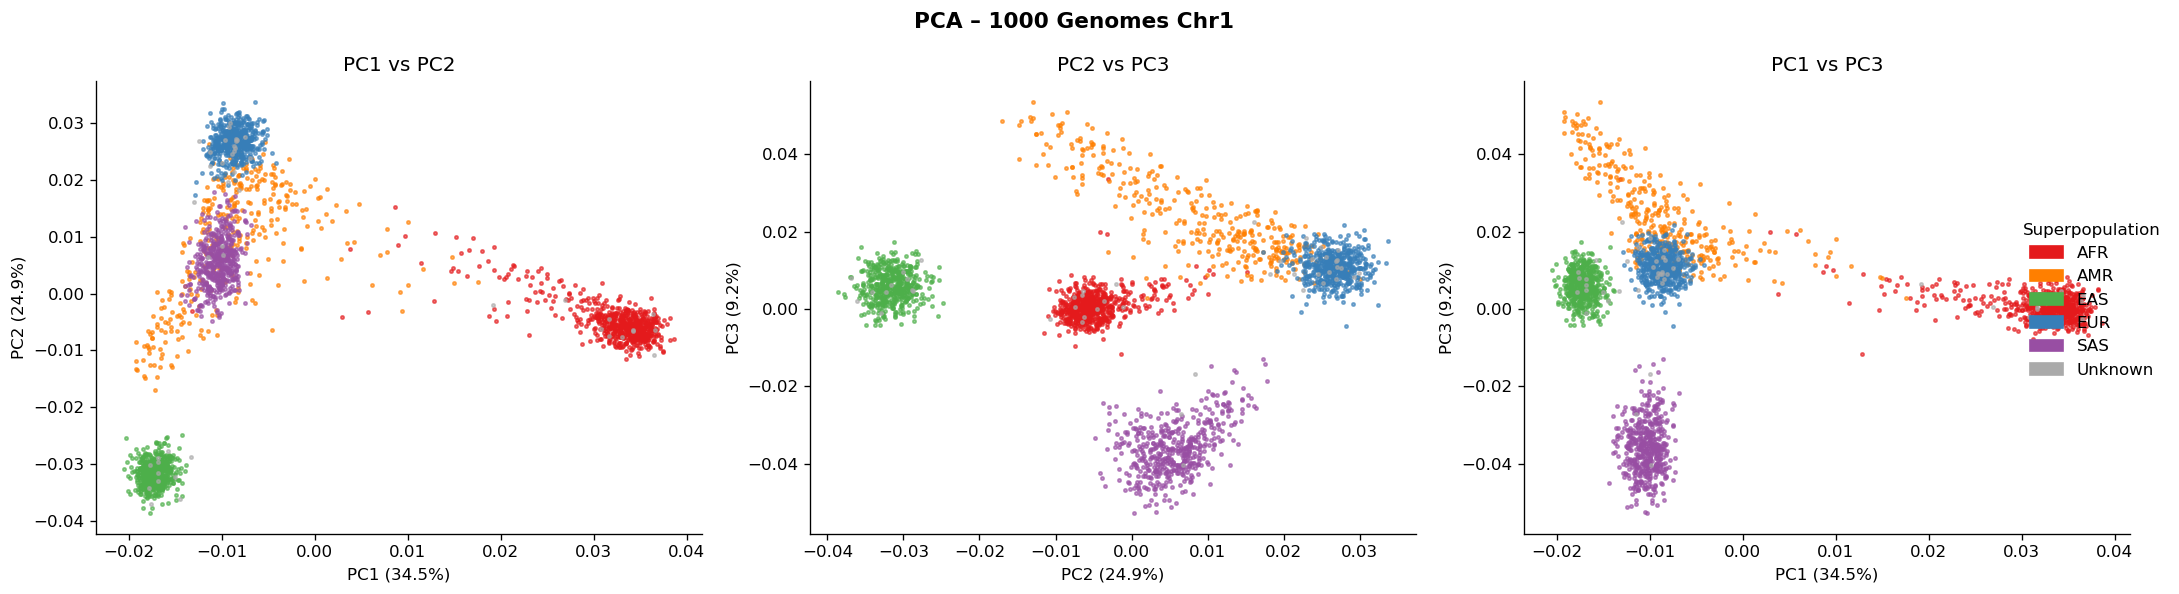

In [90]:
merged = evec.merge(panel[["IID", "super_pop", "pop"]], on="IID", how="left")
merged["super_pop"] = merged["super_pop"].fillna("Unknown")

pairs = [("PC1", "PC2"), ("PC2", "PC3"), ("PC1", "PC3")]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (pcx, pcy) in zip(axes, pairs):
    xi, yi = int(pcx[2:])-1, int(pcy[2:])-1
    for sp, grp in merged.groupby("super_pop"):
        ax.scatter(grp[pcx], grp[pcy],
                   c=SUPER_COLORS.get(sp, "#AAAAAA"),
                   s=4, alpha=0.6, label=sp, rasterized=True)
    ax.set(xlabel=f"{pcx} ({pct[xi]:.1f}%)",
           ylabel=f"{pcy} ({pct[yi]:.1f}%)",
           title=f"{pcx} vs {pcy}")

handles = [mpatches.Patch(color=v, label=k) for k, v in SUPER_COLORS.items()]
handles += [mpatches.Patch(color="#AAAAAA", label="Unknown")]
fig.legend(handles=handles, title="Superpopulation",
           loc="center right", bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.suptitle("PCA – 1000 Genomes Chr1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTDIR / "pca_scatter.png", bbox_inches="tight")
plt.show()

---
## 11. PCA – Highlighted by Superpopulation

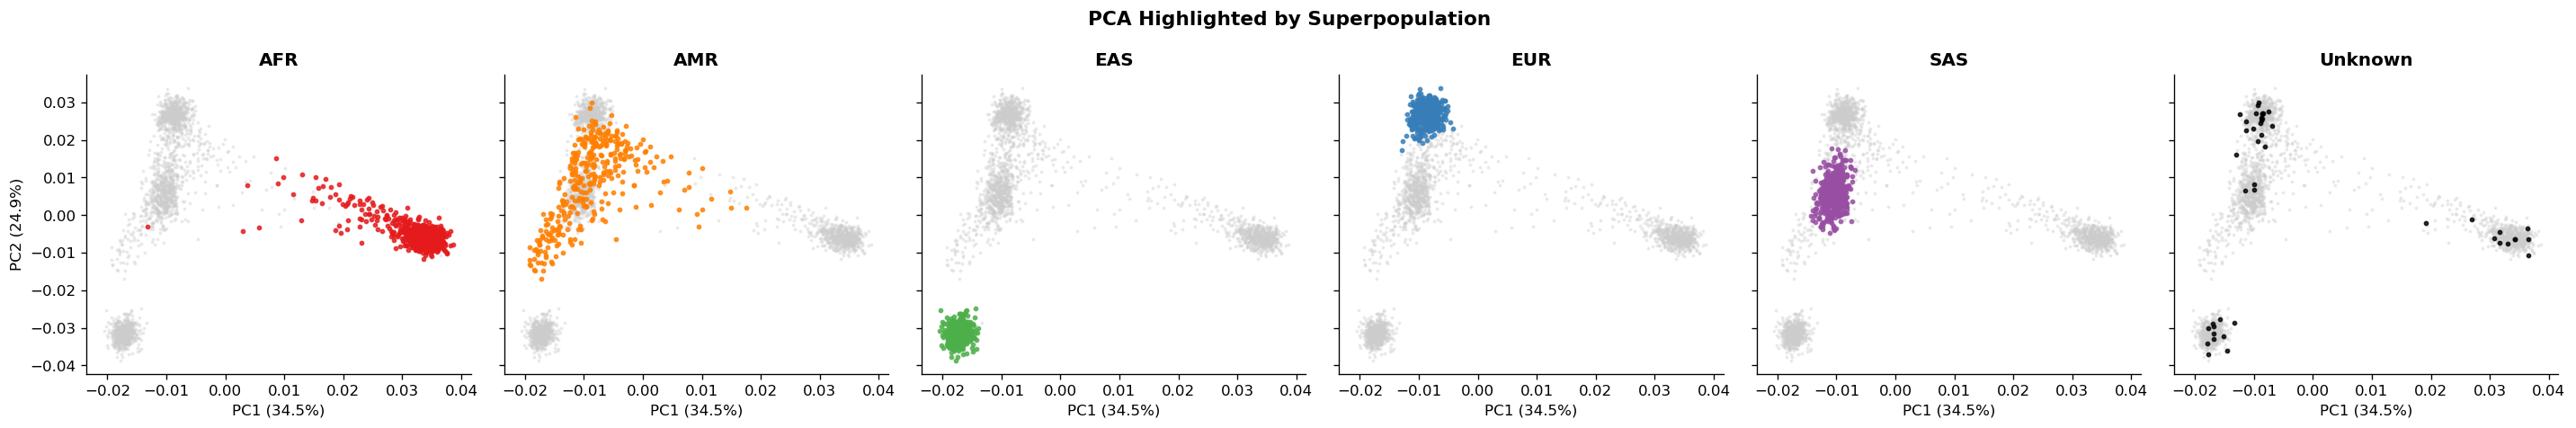

In [91]:
superpops = sorted(merged["super_pop"].dropna().unique())
fig, axes = plt.subplots(1, len(superpops), figsize=(4*len(superpops), 4),
                         sharex=True, sharey=True)

for ax, sp in zip(axes, superpops):
    bg = merged[merged["super_pop"] != sp]
    fg = merged[merged["super_pop"] == sp]
    ax.scatter(bg["PC1"], bg["PC2"], c="#CCCCCC", s=2, alpha=0.3, rasterized=True)
    ax.scatter(fg["PC1"], fg["PC2"], c=SUPER_COLORS.get(sp, "#000"),
               s=6, alpha=0.8, rasterized=True)
    ax.set_title(sp, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pct[0]:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pct[1]:.1f}%)")

plt.suptitle("PCA Highlighted by Superpopulation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTDIR / "pca_by_superpop.png", bbox_inches="tight")
plt.show()

---
## 13. ADMIXTURE – Stacked Bar Plots (All K)

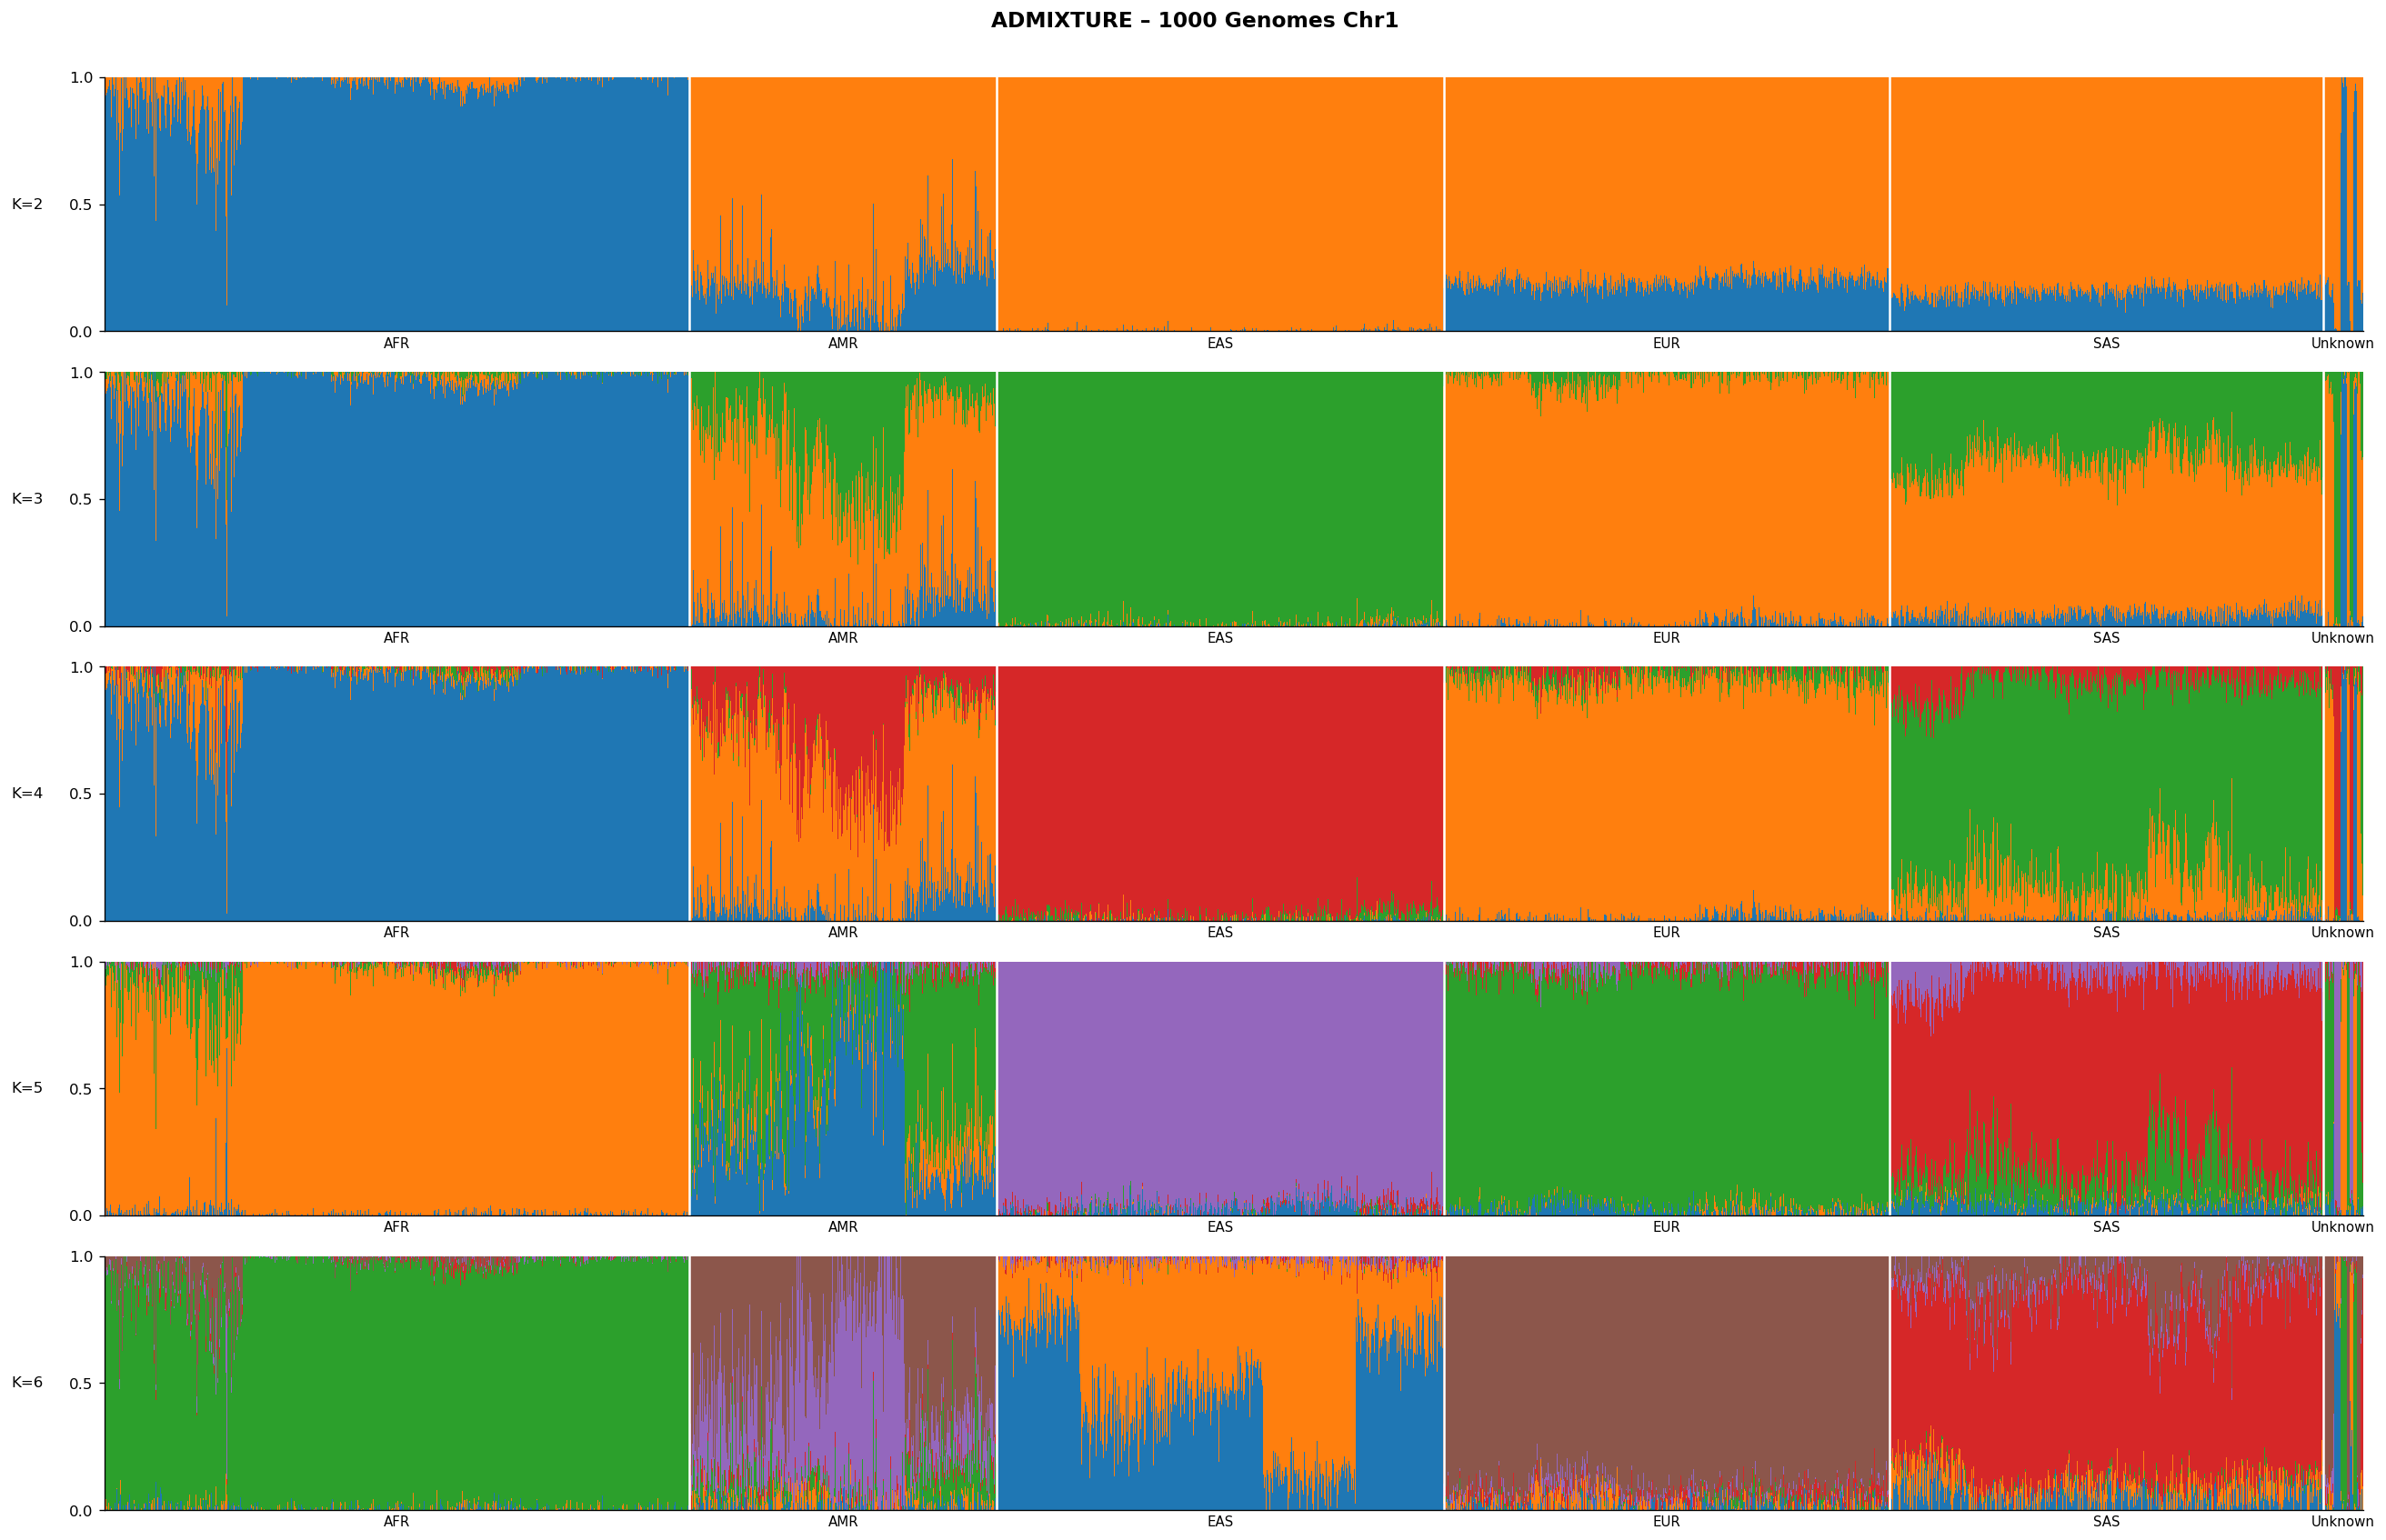

✅ All plots saved to 1000G_analysis/05_plots


In [95]:
palette = sns.color_palette("tab10", 10)
n_k = len(admix)

fig, axes = plt.subplots(n_k, 1, figsize=(22, 2.8 * n_k))
if n_k == 1:
    axes = [axes]

for ax, (k, q) in zip(axes, sorted(admix.items())):
    m = q.merge(panel[["IID", "super_pop", "pop"]], on="IID", how="left")
    m["super_pop"] = m["super_pop"].fillna("Unknown")
    m = m.sort_values(["super_pop", "pop", "IID"]).reset_index(drop=True)

    q_cols = [c for c in m.columns if c.startswith("K")]
    bottom = np.zeros(len(m))
    for i, col in enumerate(q_cols):
        ax.bar(range(len(m)), m[col].values, bottom=bottom,
               color=palette[i], width=1.0, linewidth=0)
        bottom += m[col].values

    # Superpopulation dividers and labels
    seps = [0]
    prev = None
    for idx, row in m.iterrows():
        if row["super_pop"] != prev:
            if prev is not None:
                seps.append(idx)
                ax.axvline(idx, color="white", lw=1.5)
            prev = row["super_pop"]
    seps.append(len(m))

    ticks, labels = [], []
    for i in range(len(seps)-1):
        ticks.append((seps[i] + seps[i+1]) / 2)
        labels.append(m.iloc[seps[i]]["super_pop"])

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlim(0, len(m))
    ax.set_ylim(0, 1)
    ax.set_ylabel(f"K={k}", rotation=0, labelpad=28, va="center", fontsize=10)
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(axis="x", length=0)

plt.suptitle("ADMIXTURE – 1000 Genomes Chr1", fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(PLOTDIR / "admixture_barplot.png", bbox_inches="tight")
plt.show()
print(f"✅ All plots saved to {PLOTDIR}")